In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns
import numpy as np

# 日本語フォントの設定（環境に合わせて設定してください）
plt.rcParams["font.family"] = "Yu Gothic"   # Windows
#plt.rcParams['font.family'] = 'sans-serif' # Windowsなど
# plt.rcParams['font.family'] = 'AppleGothic' # Macの場合

# 1. データの読み込み
# 実際のファイル名やパスに合わせて変更してください
df = pd.read_csv('./Database/Benesse/1571.csv', encoding='utf-8-sig')
# ここではダミーとしてdfが読み込まれていると仮定します

C:\Users\81808\AppData\Local\Temp\ipykernel_15652\3761872649.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parent_info_score', y='child_experience_score', data=df_relation, palette='coolwarm')


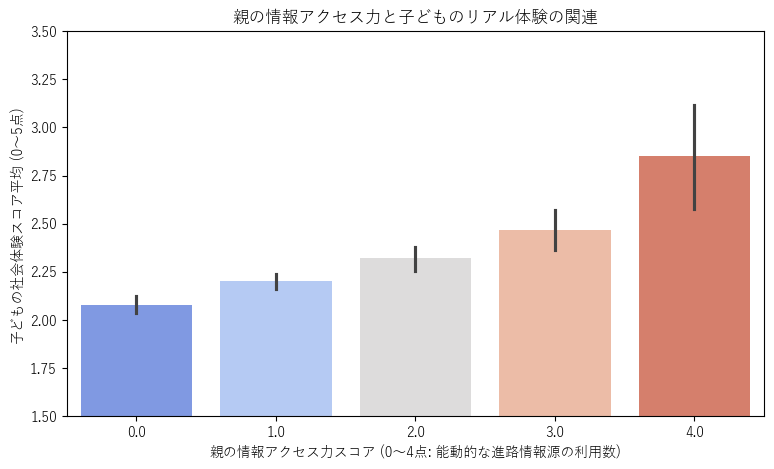

■ 集計①：親の情報収集行動の多さごとの、子どもの体験数平均


,親の情報アクセス力スコア,子どもの社会体験スコア平均
0,0.0,2.075798
1,1.0,2.200000
2,2.0,2.321700
3,3.0,2.469799
4,4.0,2.852941



重回帰分析による「体験格差」を決定づける要因の検証
                              OLS Regression Results                              
Dep. Variable:     child_experience_score   R-squared:                       0.013
Model:                                OLS   Adj. R-squared:                  0.013
Method:                     Least Squares   F-statistic:                     71.51
Date:                    Mon, 17 Aug 2026   Prob (F-statistic):           1.42e-31
Time:                            15:33:22   Log-Likelihood:                -18164.
No. Observations:                   10485   AIC:                         3.633e+04
Df Residuals:                       10482   BIC:                         3.636e+04
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display

# =========================================================
# 分析：情報格差と体験格差の関連（アプリの理論的裏付け）
# =========================================================

# 分析に必要な変数の抽出（Wave 1のデータを使用）
columns_relation = [
    'ds0000000052_w1p', # 昨年の世帯収入（親）: 1(200万未満)〜10(2000万以上), 11(答えたくない) [4, 5]
    
    # 【情報格差の指標】親の能動的な進路情報源（複数選択） [1, 2]
    'ds0000000559_w1p', # 情報源：インターネットの情報サイト (0:非選択, 1:選択) [2]
    'ds0000000560_w1p', # 情報源：インターネットの掲示板・ブログ・SNS (0:非選択, 1:選択) [2]
    'ds0000000557_w1p', # 情報源：書籍（専門書など） (0:非選択, 1:選択) [2]
    'ds0000000554_w1p', # 情報源：学習塾の先生 (0:非選択, 1:選択) [2]
    
    # 【体験格差の指標】子どもの学校外でのリアル体験（複数選択） [3]
    'ds0000000268_w1c', # 経験：家族で旅行をする (0:非選択, 1:選択) [3]
    'ds0000000270_w1c', # 経験：自然の中で思いっきり遊ぶ (0:非選択, 1:選択) [3]
    'ds0000000271_w1c', # 経験：美術館や博物館に行く (0:非選択, 1:選択) [3]
    'ds0000000275_w1c', # 経験：地域の行事に参加する (0:非選択, 1:選択) [3]
    'ds0000000276_w1c'  # 経験：ボランティア活動に参加する (0:非選択, 1:選択) [3]
]

df_relation = df[columns_relation].copy()

# 安全のため数値型に変換
df_relation = df_relation.apply(pd.to_numeric, errors='coerce')

# 欠損値（7777, 8888, 9999）を一括でNaNに置換して除外 [6]
for col in columns_relation:
    df_relation[col] = df_relation[col].replace(7777, np.nan)
    df_relation[col] = df_relation[col].replace(8888, np.nan)
    df_relation[col] = df_relation[col].replace(9999, np.nan)

# 世帯収入の「11:答えたくない」も数値分析から除外するためにNaNに置換 [5]
df_relation['ds0000000052_w1p'] = df_relation['ds0000000052_w1p'].replace(11, np.nan)

df_relation = df_relation.dropna()

# ---------------------------------------------------------
# 指標（スコア）の作成
# ---------------------------------------------------------
# ① 親の情報アクセス力スコア（0〜4点）
# 能動的な情報源にいくつアクセスしているかを合算
df_relation['parent_info_score'] = (
    df_relation['ds0000000559_w1p'] + 
    df_relation['ds0000000560_w1p'] + 
    df_relation['ds0000000557_w1p'] + 
    df_relation['ds0000000554_w1p']
)

# ② 子どもの社会体験スコア（0〜5点）
# 学校外でのリアル体験の合計経験数
df_relation['child_experience_score'] = (
    df_relation['ds0000000268_w1c'] + 
    df_relation['ds0000000270_w1c'] + 
    df_relation['ds0000000271_w1c'] + 
    df_relation['ds0000000275_w1c'] + 
    df_relation['ds0000000276_w1c']
)

# ---------------------------------------------------------
# 分析①：親の情報アクセス力と子どもの体験の単純クロス集計
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.barplot(x='parent_info_score', y='child_experience_score', data=df_relation, palette='coolwarm')
plt.title('親の情報アクセス力と子どものリアル体験の関連')
plt.xlabel('親の情報アクセス力スコア (0〜4点: 能動的な進路情報源の利用数)')
plt.ylabel('子どもの社会体験スコア平均 (0〜5点)')
plt.ylim(1.5, 3.5)
plt.show()

# 数値表の表示
info_exp_table = df_relation.groupby('parent_info_score')['child_experience_score'].mean().reset_index()
info_exp_table.columns = ['親の情報アクセス力スコア', '子どもの社会体験スコア平均']
print("■ 集計①：親の情報収集行動の多さごとの、子どもの体験数平均")
display(info_exp_table)


# ---------------------------------------------------------
# 分析②：経済力（収入）をコントロールした重回帰分析
# ---------------------------------------------------------
# 目的変数：子どもの社会体験スコア
# 説明変数：親の世帯収入、親の情報アクセス力スコア
X = df_relation[['ds0000000052_w1p', 'parent_info_score']]
X = sm.add_constant(X) # 切片を追加
y = df_relation['child_experience_score']

model_relation = sm.OLS(y, X).fit()

print("\n" + "="*60)
print("重回帰分析による「体験格差」を決定づける要因の検証")
print("="*60)
print(model_relation.summary())
print("\n※ ds0000000052_w1p = 世帯収入の影響（経済格差）")
print("※ parent_info_score = 親の情報アクセス力の影響（情報格差）")
print("※ P>|t| が 0.05 未満であれば、その要因は子どもの体験数に有意な影響を与えています。")


C:\Users\81808\AppData\Local\Temp\ipykernel_15652\3326471764.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parent_edu_label', y='aim_univ', data=df_analysis1, palette='Set2')
C:\Users\81808\AppData\Local\Temp\ipykernel_15652\3326471764.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parent_edu_label', y='challenge_spirit', data=df_analysis1, palette='Set2')


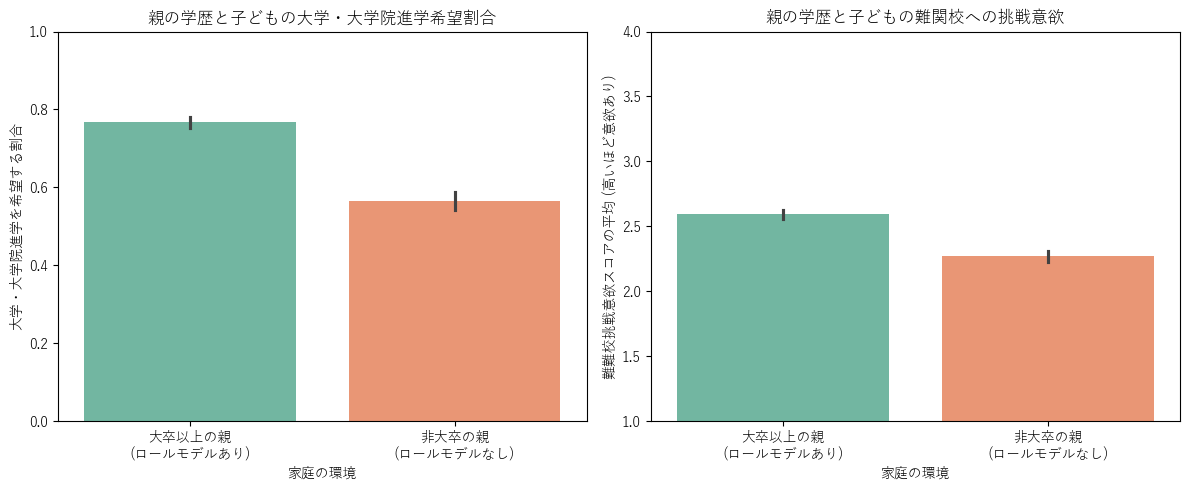

■ 集計結果：親の学歴環境ごとの、子どもの大学進学希望割合と挑戦意欲スコア平均


,親の学歴環境,大学進学希望割合,難関校挑戦意欲スコア平均
0,大卒以上の親\n(ロールモデルあり),0.766900,2.591742
1,非大卒の親\n(ロールモデルなし),0.565533,2.268265


In [11]:
# =========================================================
# 分析①：身近な環境（親の学歴）による「見えない進路の壁」の可視化
# =========================================================

# 分析に必要な変数の抽出
columns_analysis1 = [
    'ds0000000049_w1p', # 保護者最終学歴
    'ds0000000046_w1p', # 配偶者最終学歴
    'ds0000000198_w6c', # 子Wave6希望進学段階
    'ds0000000371_w6c'  # 子Wave6難関校挑戦意欲
]

df_analysis1 = df[columns_analysis1].copy()

# 欠損値（7777, 8888, 9999）を一括でNaNに置換して除外 [1]
for col in columns_analysis1:
    df_analysis1[col] = df_analysis1[col].replace(7777, np.nan)
    df_analysis1[col] = df_analysis1[col].replace(8888, np.nan)
    df_analysis1[col] = df_analysis1[col].replace(9999, np.nan)

# さらに希望進学段階の「9: まだ決めていない」「8:その他」もNaNに置換
df_analysis1['ds0000000198_w6c'] = df_analysis1['ds0000000198_w6c'].replace([2, 3], np.nan)

df_analysis1 = df_analysis1.dropna()

# ---------------------------------------------------------
# データの加工
# ---------------------------------------------------------
# ① 親の最終学歴が大卒以上（5:大学, 6:大学院）かどうか
# どちらかが5または6なら1、そうでなければ0
df_analysis1['has_univ_parent'] = df_analysis1.apply(
    lambda row: 1 if row['ds0000000049_w1p'] in [5, 6] or row['ds0000000046_w1p'] in [5, 6] else 0, 
    axis=1
)

# ② 子どもの大学・大学院進学希望 (6:大学, 7:大学院 なら1, それ以外は0)
df_analysis1['aim_univ'] = df_analysis1['ds0000000198_w6c'].apply(lambda x: 1 if x in [6, 7] else 0)

# ③ 難関校挑戦意欲スコアの反転（値が大きいほど意欲が高いよう反転：5 - 現在の値）
df_analysis1['challenge_spirit'] = 5 - df_analysis1['ds0000000371_w6c']

# グラフ用ラベル
df_analysis1['parent_edu_label'] = df_analysis1['has_univ_parent'].map(
    {1: '大卒以上の親\n(ロールモデルあり)', 0: '非大卒の親\n(ロールモデルなし)'}
)

# ---------------------------------------------------------
# グラフの描画と数値表の表示
# ---------------------------------------------------------
from IPython.display import display

plt.figure(figsize=(12, 5))

# グラフ①：進学希望割合の比較
plt.subplot(1, 2, 1)
sns.barplot(x='parent_edu_label', y='aim_univ', data=df_analysis1, palette='Set2')
plt.title('親の学歴と子どもの大学・大学院進学希望割合')
plt.xlabel('家庭の環境')
plt.ylabel('大学・大学院進学を希望する割合')
plt.ylim(0, 1)

# グラフ②：挑戦意欲スコアの比較
plt.subplot(1, 2, 2)
sns.barplot(x='parent_edu_label', y='challenge_spirit', data=df_analysis1, palette='Set2')
plt.title('親の学歴と子どもの難関校への挑戦意欲')
plt.xlabel('家庭の環境')
plt.ylabel('難難校挑戦意欲スコアの平均 (高いほど意欲あり)')
plt.ylim(1, 4)

plt.tight_layout()
plt.show()

# 数値表の表示
print("■ 集計結果：親の学歴環境ごとの、子どもの大学進学希望割合と挑戦意欲スコア平均")
grouped1 = df_analysis1.groupby('parent_edu_label')[['aim_univ', 'challenge_spirit']].mean().reset_index()
grouped1.columns = ['親の学歴環境', '大学進学希望割合', '難関校挑戦意欲スコア平均']
display(grouped1)

In [14]:
import scipy.stats as stats
from IPython.display import display

# =========================================================
# 分析①のグラフの差に対する統計的仮説検定
# =========================================================

print("=========================================================")
print("分析①：親の学歴（ロールモデルの有無）による格差の統計的検証")
print("=========================================================\n")

# ---------------------------------------------------------
# 検定①：大学・大学院進学希望割合の差（カイ二乗検定）
# ---------------------------------------------------------
# クロス集計表（分割表）を作成
contingency_table = pd.crosstab(df_analysis1['has_univ_parent'], df_analysis1['aim_univ'])

# 表示用に見やすいラベルを設定
contingency_table_labeled = contingency_table.copy()
contingency_table_labeled.index = ['非大卒の親 (ロールモデルなし)', '大卒以上の親 (ロールモデルあり)']
contingency_table_labeled.columns = ['その他進路/未定', '大学・大学院進学希望']

print("【検定①】進学希望に関するクロス集計表（実人数）:")
display(contingency_table_labeled)

# カイ二乗検定を実行
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n--- 独立性のカイ二乗検定 結果 ---")
print(f"カイ二乗統計量 (Chi-squared): {chi2:.4f}")
print(f"自由度 (dof): {dof}")
print(f"p値 (p-value): {p_value_chi2:.4e}")  # 非常に小さいp値に対応するため指数表記

if p_value_chi2 < 0.05:
    print("⇒ 判定：【 統計的に有意な差あり (p < 0.05) 】")
    print("  親が大卒以上かそうでないかによって、子どもの大学進学希望率には「明確な格差」が存在します。")
else:
    print("⇒ 判定：【 有意な差なし (p >= 0.05) 】")
    print("  親の学歴による子どもの大学進学希望率の差は、誤差の範囲内である可能性があります。")


print("\n" + "="*57 + "\n")

# ---------------------------------------------------------
# 検定②：難関校挑戦意欲スコアの平均値の差（ウェルチのt検定）
# ---------------------------------------------------------
# 2つのグループの意欲スコアデータを抽出
group_univ = df_analysis1[df_analysis1['has_univ_parent'] == 1]['challenge_spirit']
group_non_univ = df_analysis1[df_analysis1['has_univ_parent'] == 0]['challenge_spirit']

print("【検定②】難関校挑戦意欲スコアの比較:")
print(f"大卒親グループの意欲平均: {group_univ.mean():.4f}点 (サンプル数: {len(group_univ)}人)")
print(f"非大卒親グループの意欲平均: {group_non_univ.mean():.4f}点 (サンプル数: {len(group_non_univ)}人)")

# ウェルチのt検定を実行 (equal_var=False)
t_stat, p_value_t = stats.ttest_ind(group_univ, group_non_univ, equal_var=False)

print("\n--- ウェルチのt検定 (Welch's t-test) 結果 ---")
print(f"t値 (t-statistic): {t_stat:.4f}")
print(f"p値 (p-value): {p_value_t:.4e}")

if p_value_t < 0.05:
    print("⇒ 判定：【 統計的に有意な差あり (p < 0.05) 】")
    print("  親の学歴の違いによって、子どもの難関校への挑戦意欲には統計的に「明確な格差」が存在します。")
else:
    print("⇒ 判定：【 有意な差なし (p >= 0.05) 】")
    print("  挑戦意欲スコアの差は、統計的に確実な差とは言えず、偶然のばらつきの可能性があります。")
print("=========================================================")


分析①：親の学歴（ロールモデルの有無）による格差の統計的検証

【検定①】進学希望に関するクロス集計表（実人数）:


,その他進路/未定,大学・大学院進学希望
非大卒の親 (ロールモデルなし),779,1014
大卒以上の親 (ロールモデルあり),700,2303



--- 独立性のカイ二乗検定 結果 ---
カイ二乗統計量 (Chi-squared): 212.4982
自由度 (dof): 1
p値 (p-value): 3.9161e-48
⇒ 判定：【 統計的に有意な差あり (p < 0.05) 】
  親が大卒以上かそうでないかによって、子どもの大学進学希望率には「明確な格差」が存在します。


【検定②】難関校挑戦意欲スコアの比較:
大卒親グループの意欲平均: 2.5917点 (サンプル数: 3003人)
非大卒親グループの意欲平均: 2.2683点 (サンプル数: 1793人)

--- ウェルチのt検定 (Welch's t-test) 結果 ---
t値 (t-statistic): 11.1051
p値 (p-value): 3.1800e-28
⇒ 判定：【 統計的に有意な差あり (p < 0.05) 】
  親の学歴の違いによって、子どもの難関校への挑戦意欲には統計的に「明確な格差」が存在します。


C:\Users\81808\AppData\Local\Temp\ipykernel_15652\1464443128.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='adult_talk_freq', y='challenge_spirit_w6', data=df_analysis2, palette='Blues')
C:\Users\81808\AppData\Local\Temp\ipykernel_15652\1464443128.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='adult_talk_freq', y='clear_target_w6', data=df_analysis2, palette='Blues')


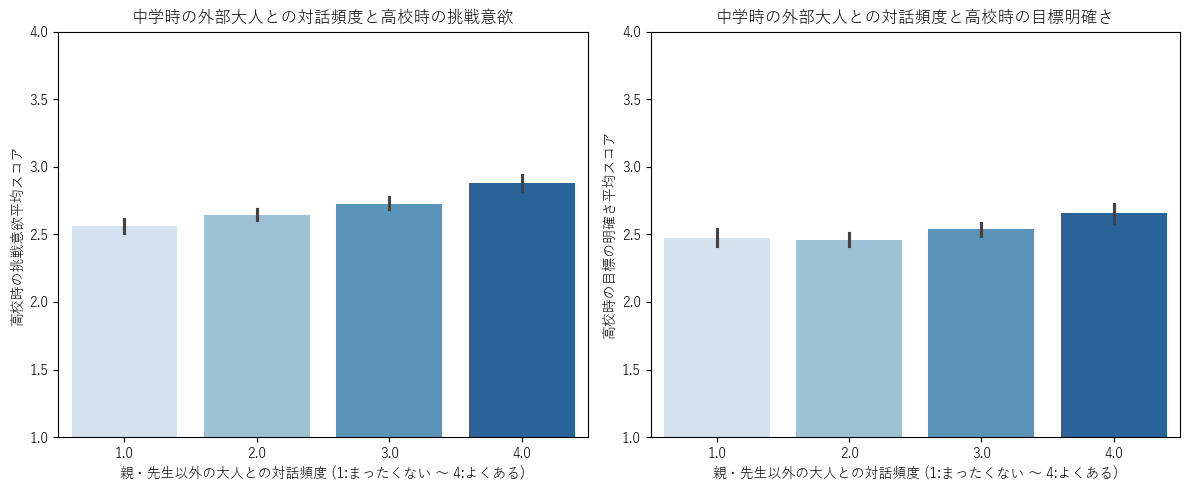

■ 分析②-1：高校時の「挑戦意欲」に対する、中学時の外部大人との対話効果（世帯収入をコントロール）


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     challenge_spirit_w6   R-squared:                       0.016
Model:                             OLS   Adj. R-squared:                  0.016
Method:                  Least Squares   F-statistic:                     38.98
Date:                 Tue, 18 Aug 2026   Prob (F-statistic):           1.61e-17
Time:                         15:30:02   Log-Likelihood:                -5907.8
No. Observations:                 4749   AIC:                         1.182e+04
Df Residuals:                     4746   BIC:                         1.184e+04
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.3394      0.048     48.315      0.000       2.244       2.434
ds0000000052_w6p     0.0194      0.006      3.008      0.003       0.007       0.032
adult_talk_freq      0.0988      0.012      8.172      0.000       0.075       0.123
==============================================================================
Omnibus:                      191.999   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               85.641
Skew:                          -0.072   Prob(JB):                     2.53e-19
Kurtosis:                       2.358   Cond. No.                         26.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


■ 分析②-2：高校時の「将来目標の明確さ」に対する、中学時の外部大人との対話効果（世帯収入をコントロール）


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        clear_target_w6   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     8.748
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           0.000161
Time:                        15:30:02   Log-Likelihood:                -6719.8
No. Observations:                4749   AIC:                         1.345e+04
Df Residuals:                    4746   BIC:                         1.346e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.3544      0.057     40.984      0.000       2.242       2.467
ds0000000052_w6p     0.0038      0.008      0.502      0.616      -0.011       0.019
adult_talk_freq      0.0592      0.014      4.129      0.000       0.031       0.087
==============================================================================
Omnibus:                     1500.613   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.463
Skew:                           0.075   Prob(JB):                     6.67e-50
Kurtosis:                       1.941   Cond. No.                         26.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
# =========================================================
# 分析②：親以外の「外部ロールモデル接触」が意欲を底上げする効果の証明
# =========================================================

# 分析に必要な変数の抽出
columns_analysis2 = [
    'ds0000000052_w6p', # Wave6昨年の世帯収入
    'ds0000000720_w3c', # Wave3親や先生以外の大人と話をする
    'ds0000000363_w6c', # Wave6難しい・新しいことに挑戦したい（挑戦意欲）
    'ds0000000368_w6c'  # Wave6将来の目標がはっきりしている（目標明確さ）
]

df_analysis2 = df[columns_analysis2].copy()

# 欠損値（7777, 8888, 9999）を一括でNaNに置換して除外 [1]
for col in columns_analysis2:
    df_analysis2[col] = df_analysis2[col].replace(7777, np.nan)
    df_analysis2[col] = df_analysis2[col].replace(8888, np.nan)
    df_analysis2[col] = df_analysis2[col].replace(9999, np.nan)

# 世帯収入の「11:答えたくない」も除外
df_analysis2['ds0000000052_w6p'] = df_analysis2['ds0000000052_w6p'].replace(11, np.nan)

df_analysis2 = df_analysis2.dropna()

# ---------------------------------------------------------
# データの加工
# ---------------------------------------------------------
# ① 中学時の外部大人との対話頻度（値が大きいほど会話が多いよう反転：5 - w3c）
df_analysis2['adult_talk_freq'] = 5 - df_analysis2['ds0000000720_w3c']

# ② 高校時の挑戦意欲スコアの反転（5 - w6c）
df_analysis2['challenge_spirit_w6'] = 5 - df_analysis2['ds0000000363_w6c']

# ③ 高校時の目標明確さスコアの反転（5 - w6c）
df_analysis2['clear_target_w6'] = 5 - df_analysis2['ds0000000368_w6c']

# ---------------------------------------------------------
# グラフの描画と数値表の表示
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# グラフ①：外部大人との話す頻度と挑戦意欲
plt.subplot(1, 2, 1)
sns.barplot(x='adult_talk_freq', y='challenge_spirit_w6', data=df_analysis2, palette='Blues')
plt.title('中学時の外部大人との対話頻度と高校時の挑戦意欲')
plt.xlabel('親・先生以外の大人との対話頻度 (1:まったくない 〜 4:よくある)')
plt.ylabel('高校時の挑戦意欲平均スコア')
plt.ylim(1, 4)

# グラフ②：外部大人との話す頻度と目標の明確さ
plt.subplot(1, 2, 2)
sns.barplot(x='adult_talk_freq', y='clear_target_w6', data=df_analysis2, palette='Blues')
plt.title('中学時の外部大人との対話頻度と高校時の目標明確さ')
plt.xlabel('親・先生以外の大人との対話頻度 (1:まったくない 〜 4:よくある)')
plt.ylabel('高校時の目標の明確さ平均スコア')
plt.ylim(1, 4)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 重回帰分析 OLS による統計的な検証
# ---------------------------------------------------------
import statsmodels.api as sm

print("■ 分析②-1：高校時の「挑戦意欲」に対する、中学時の外部大人との対話効果（世帯収入をコントロール）")
X1 = df_analysis2[['ds0000000052_w6p', 'adult_talk_freq']]
X1 = sm.add_constant(X1)
y1 = df_analysis2['challenge_spirit_w6']
model1 = sm.OLS(y1, X1).fit()
display(model1.summary())

print("\n■ 分析②-2：高校時の「将来目標の明確さ」に対する、中学時の外部大人との対話効果（世帯収入をコントロール）")
X2 = df_analysis2[['ds0000000052_w6p', 'adult_talk_freq']]
X2 = sm.add_constant(X2)
y2 = df_analysis2['clear_target_w6']
model2 = sm.OLS(y2, X2).fit()
display(model2.summary())

C:\Users\81808\AppData\Local\Temp\ipykernel_15652\3544369886.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='adult_talk_label', y='ds0000000280_w7c', data=df_analysis3, palette='Pastel1')
C:\Users\81808\AppData\Local\Temp\ipykernel_15652\3544369886.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='adult_talk_label', y='self_decision_skill_w7', data=df_analysis3, palette='Pastel1')


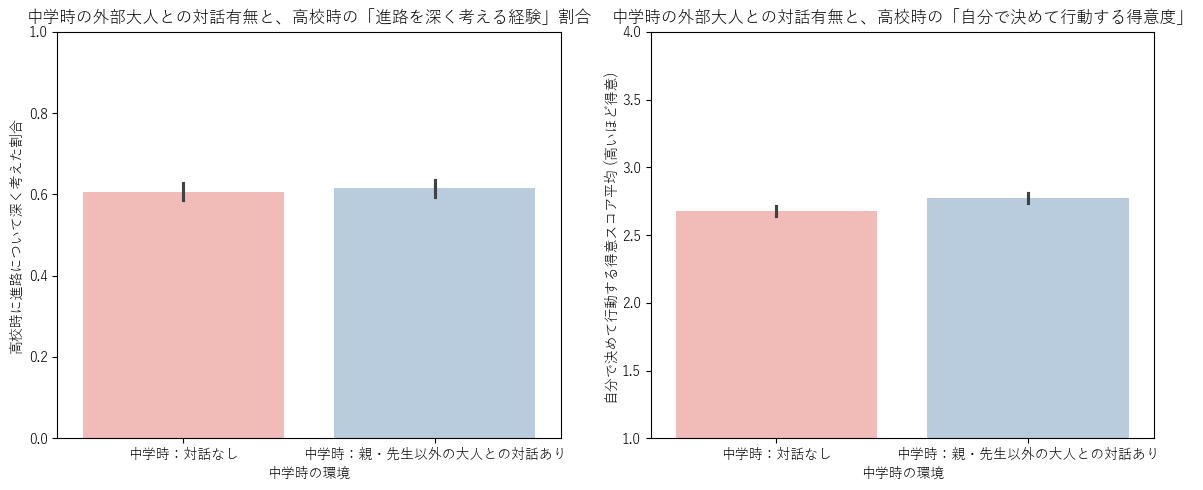

■ 集計結果：中学時の外部大人との対話有無による、高校時（Wave 7）のキャリア行動の差異


,中学時の対話環境,高校時：進路を深く考えた割合,高校時：自律的決定の得意スコア平均
0,中学時：対話なし,0.605725,2.679132
1,中学時：親・先生以外の大人との対話あり,0.614890,2.773438


In [12]:
# =========================================================
# 分析③：早期接触の因果関係（時間差効果）の証明
# =========================================================

# 分析に必要な変数の抽出
columns_analysis3 = [
    'ds0000000720_w3c', # Wave3親や先生以外の大人と話をする
    'ds0000000280_w7c', # Wave7進路について深く考える（子経験）
    'ds0000000336_w7c'  # Wave7自分で決めて行動すること（得意・苦手）
]

df_analysis3 = df[columns_analysis3].copy()

# 欠損値（7777, 8888, 9999）を一括でNaNに置換して除外 [1]
for col in columns_analysis3:
    df_analysis3[col] = df_analysis3[col].replace(7777, np.nan)
    df_analysis3[col] = df_analysis3[col].replace(8888, np.nan)
    df_analysis3[col] = df_analysis3[col].replace(9999, np.nan)

df_analysis3 = df_analysis3.dropna()

# ---------------------------------------------------------
# データの加工
# ---------------------------------------------------------
# ① 中学時の外部の大人との対話の有無 (1:よく話す, 2:ときどき話す なら「1:対話あり」、3, 4なら「0:対話なし」)
df_analysis3['had_adult_talk_w3'] = df_analysis3['ds0000000720_w3c'].apply(lambda x: 1 if x in [1, 2] else 0)

# ② 高校時の「自分で決めて行動すること」の得意スコアの反転（5 - w7c）
df_analysis3['self_decision_skill_w7'] = 5 - df_analysis3['ds0000000336_w7c']

# グラフ用ラベル
df_analysis3['adult_talk_label'] = df_analysis3['had_adult_talk_w3'].map(
    {1: '中学時：親・先生以外の大人との対話あり', 0: '中学時：対話なし'}
)

# ---------------------------------------------------------
# グラフの描画と数値表の表示
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# グラフ①：進路について深く考える経験の比較
plt.subplot(1, 2, 1)
sns.barplot(x='adult_talk_label', y='ds0000000280_w7c', data=df_analysis3, palette='Pastel1')
plt.title('中学時の外部大人との対話有無と、高校時の「進路を深く考える経験」割合')
plt.xlabel('中学時の環境')
plt.ylabel('高校時に進路について深く考えた割合')
plt.ylim(0, 1)

# グラフ②：自分で決めて行動することの得意スコアの比較
plt.subplot(1, 2, 2)
sns.barplot(x='adult_talk_label', y='self_decision_skill_w7', data=df_analysis3, palette='Pastel1')
plt.title('中学時の外部大人との対話有無と、高校時の「自分で決めて行動する得意度」')
plt.xlabel('中学時の環境')
plt.ylabel('自分で決めて行動する得意スコア平均 (高いほど得意)')
plt.ylim(1, 4)

plt.tight_layout()
plt.show()

# 集計表の表示
print("■ 集計結果：中学時の外部大人との対話有無による、高校時（Wave 7）のキャリア行動の差異")
grouped3 = df_analysis3.groupby('adult_talk_label')[['ds0000000280_w7c', 'self_decision_skill_w7']].mean().reset_index()
grouped3.columns = ['中学時の対話環境', '高校時：進路を深く考えた割合', '高校時：自律的決定の得意スコア平均']
display(grouped3)